<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/X_Ray_dataset_20_8_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


### Organize X-ray Image Data for CNN

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define base directories for the dataset
base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Define class names based on the identified X-ray images
# For simplicity, we'll categorize them into 'NORMAL' and 'PNEUMONIA'
# based on keywords in their filenames. This might need adjustment for a real dataset.
class_names = ['NORMAL', 'PNEUMONIA']

# Create the base directory if it doesn't exist
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

# Create train and validation directories for each class
for class_name in class_names:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(validation_dir, class_name), exist_ok=True)

# Get all image files from /content/
all_files = [f for f in os.listdir('/content/') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Categorize files based on keywords and split them into train/validation
normal_files = [f for f in all_files if 'normal' in f.lower()]
pneumonia_files = [f for f in all_files if 'pneumonia' in f.lower() or 'covid' in f.lower() or 'sars' in f.lower() or 'ards' in f.lower() or 'streptococcus' in f.lower()]

# For files not explicitly categorized, put them into pneumonia for this demonstration,
# but in a real scenario, these would require careful manual inspection or better labeling.
uncategorized_files = [f for f in all_files if f not in normal_files and f not in pneumonia_files]
pneumonia_files.extend(uncategorized_files)

print(f"Found {len(normal_files)} 'NORMAL' images and {len(pneumonia_files)} 'PNEUMONIA' images.")

# Split files into training and validation sets (80/20 split)
train_normal, val_normal = train_test_split(normal_files, test_size=0.2, random_state=42)
train_pneumonia, val_pneumonia = train_test_split(pneumonia_files, test_size=0.2, random_state=42)

# Function to copy files
def copy_files(file_list, destination_dir, class_label):
    for fname in file_list:
        src = os.path.join('/content/', fname)
        dst = os.path.join(destination_dir, class_label, fname)
        shutil.copyfile(src, dst)

print("Copying files...")
# Copy training files
copy_files(train_normal, train_dir, 'NORMAL')
copy_files(train_pneumonia, train_dir, 'PNEUMONIA')

# Copy validation files
copy_files(val_normal, validation_dir, 'NORMAL')
copy_files(val_pneumonia, validation_dir, 'PNEUMONIA')

print("Data organization complete. Directory structure:")
for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Found 32 'NORMAL' images and 162 'PNEUMONIA' images.
Copying files...
Data organization complete. Directory structure:
dataset/
    train/
        NORMAL/
            NORMAL2-IM-0035-0001.jpeg
            NORMAL2-IM-0012-0001.jpeg
            NORMAL2-IM-0052-0001.jpeg
            NORMAL2-IM-0132-0001.jpeg
            NORMAL2-IM-0092-0001.jpeg
            NORMAL2-IM-0120-0001.jpeg
            NORMAL2-IM-0171-0001.jpeg
            NORMAL2-IM-0145-0001.jpeg
            NORMAL2-IM-0030-0001.jpeg
            NORMAL2-IM-0033-0001.jpeg
            NORMAL2-IM-0072-0001.jpeg
            NORMAL2-IM-0112-0001.jpeg
            normal_or_pneumonia1.jpeg
            NORMAL2-IM-0007-0001.jpeg
            NORMAL2-IM-0028-0001.jpeg
            NORMAL2-IM-0131-0001.jpeg
            NORMAL2-IM-0110-0001.jpeg
            NORMAL2-IM-0029-0001.jpeg
            NORMAL2-IM-0139-0001.jpeg
            NORMAL2-IM-0058-0001.jpeg
            NORMAL2-IM-0117-0001.jpeg
            NORMAL2-IM-0013-0001.jpeg
         

### Load Data using `ImageDataGenerator`

In [ ]:
# Initialize ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Initialize ImageDataGenerator for validation (only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128), # Adjust target size as needed
    batch_size=32,
    class_mode='binary' # 'categorical' for more than two classes
)

# Load validation data
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

print(f"Training classes: {train_generator.class_indices}")
print(f"Validation classes: {validation_generator.class_indices}")

# Display a batch of training images and labels as an example
# x_batch, y_batch = next(train_generator)
# print(f"Shape of image batch: {x_batch.shape}") # (batch_size, height, width, channels)
# print(f"Shape of label batch: {y_batch.shape}") # (batch_size,)


Found 154 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Training classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Validation classes: {'NORMAL': 0, 'PNEUMONIA': 1}


### Define and Compile CNN Model

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # 'sigmoid' for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN Model

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10, # Adjust number of epochs as needed
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6230 - loss: 0.6743 - val_accuracy: 0.8125 - val_loss: 0.5327
Epoch 2/10
1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 890ms/step - accuracy: 0.9062 - loss: 0.4686

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.9062 - loss: 0.4686 - val_accuracy: 0.8750 - val_loss: 0.4864
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8279 - loss: 0.4754 - val_accuracy: 0.8750 - val_loss: 0.3602
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step - accuracy: 0.8750 - loss: 0.3856 - val_accuracy: 0.8125 - val_loss: 0.5597
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8361 - loss: 0.4954 - val_accuracy: 0.8438 - val_loss: 0.4235
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - accuracy: 0.8438 - loss: 0.4188 - val_accuracy: 0.7812 - val_loss: 0.5014
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.8361 - loss: 0.4309 - val_accuracy: 0.8750 - val_loss: 0.3571
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.8438 - loss: 0.4222 - val_accuracy: 0.7812 - val_loss: 0.5210
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.8516 - loss: 0.3792 - val_accuracy: 0.8750 - val_loss: 0.3578
Epoch 10/10


### Evaluate Model Performance

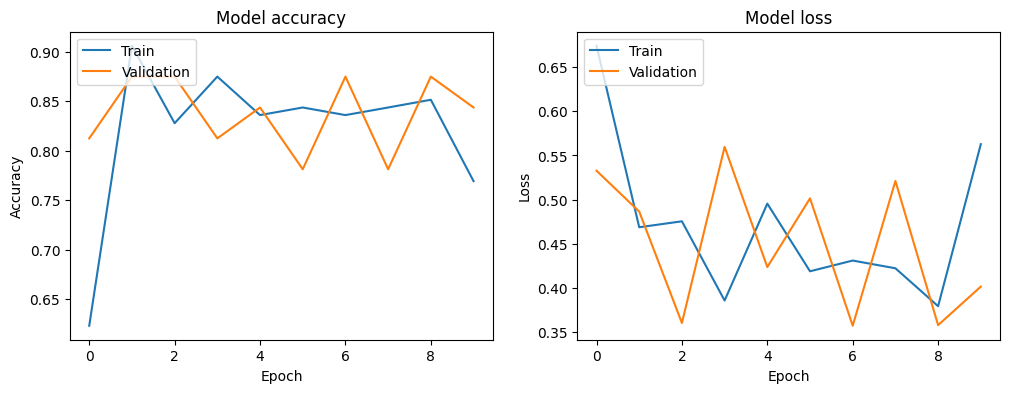

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8250 - loss: 0.4157
Validation Loss: 0.4157
Validation Accuracy: 0.8250


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
